In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv('/content/drive/MyDrive/exoplanet/exoTrain.csv')
test = pd.read_csv('/content/drive/MyDrive/exoplanet/exoTest.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train['LABEL'].value_counts())

Train shape: (5087, 3198)
Test shape: (570, 3198)
LABEL
1    5050
2      37
Name: count, dtype: int64


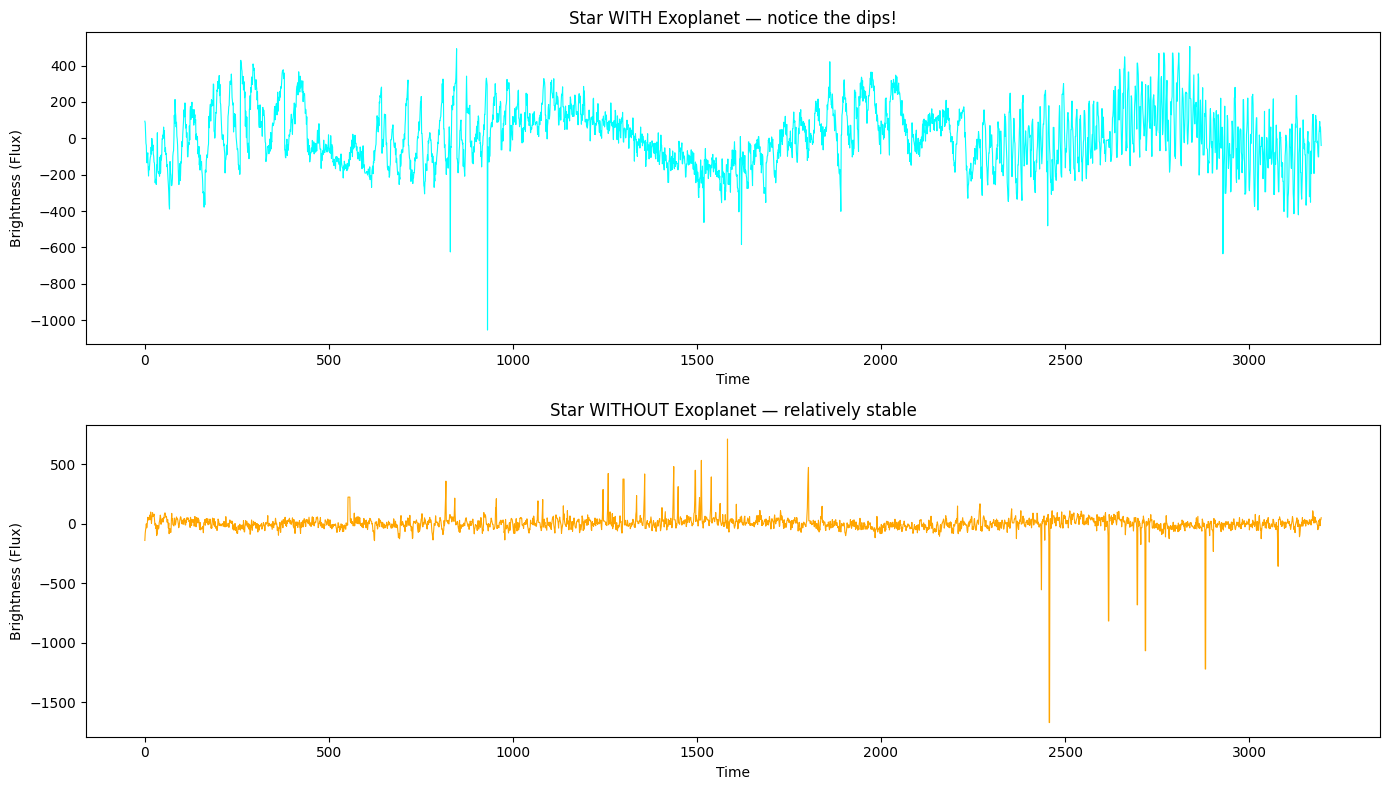

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot a star WITH a planet (label 2)
planet_star = train[train['LABEL'] == 2].iloc[0, 1:].values
no_planet_star = train[train['LABEL'] == 1].iloc[0, 1:].values

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(planet_star, color='cyan', linewidth=0.8)
axes[0].set_title('Star WITH Exoplanet — notice the dips!')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Brightness (Flux)')

axes[1].plot(no_planet_star, color='orange', linewidth=0.8)
axes[1].set_title('Star WITHOUT Exoplanet — relatively stable')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Brightness (Flux)')

plt.tight_layout()
plt.show()

In [12]:
# Separate features and labels
X_train = train.drop('LABEL', axis=1).values
y_train = train['LABEL'].values - 1  # Convert 1,2 → 0,1

X_test = test.drop('LABEL', axis=1).values
y_test = test['LABEL'].values - 1

# Normalize each star's flux independently
from sklearn.preprocessing import StandardScaler

# Normalize row by row (each star independently)
X_train = (X_train - X_train.mean(axis=1, keepdims=True)) / (X_train.std(axis=1, keepdims=True) + 1e-10)
X_test = (X_test - X_test.mean(axis=1, keepdims=True)) / (X_test.std(axis=1, keepdims=True) + 1e-10)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("\nLabel distribution after conversion:")
print("No planet (0):", (y_train == 0).sum())
print("Has planet (1):", (y_train == 1).sum())

X_train shape: (5087, 3197)
y_train shape: (5087,)

Label distribution after conversion:
No planet (0): 5050
Has planet (1): 37


In [13]:
# Install imbalanced-learn
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("No planet (0):", (y_train_balanced == 0).sum())
print("Has planet (1):", (y_train_balanced == 1).sum())
print("Total training samples:", len(X_train_balanced))

After SMOTE:
No planet (0): 5050
Has planet (1): 5050
Total training samples: 10100


In [14]:
# CNN expects 3D input: (samples, timesteps, features)
X_train_cnn = X_train_balanced.reshape(X_train_balanced.shape[0], X_train_balanced.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train_cnn shape:", X_train_cnn.shape)
print("X_test_cnn shape:", X_test_cnn.shape)

X_train_cnn shape: (10100, 3197, 1)
X_test_cnn shape: (570, 3197, 1)


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    # First Conv block
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(3197, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    # Second Conv block
    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    # Third Conv block
    Conv1D(128, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.3),

    # Classification head
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')  # Binary output
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3193, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3193, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 798, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 798, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 794, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 794, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 198, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 198, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 194, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 194, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       393,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 445,825 (1.70 MB)

 Trainable params: 445,377 (1.70 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_cnn, y_train_balanced,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - accuracy: 0.9540 - loss: 0.1392 - val_accuracy: 0.9990 - val_loss: 0.0393
Epoch 2/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9920 - loss: 0.0261 - val_accuracy: 1.0000 - val_loss: 2.7898e-04
Epoch 3/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9937 - loss: 0.0185 - val_accuracy: 1.0000 - val_loss: 5.5324e-05
Epoch 4/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9950 - loss: 0.0170 - val_accuracy: 1.0000 - val_loss: 2.2022e-04
Epoch 5/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9958 - loss: 0.0117 - val_accuracy: 1.0000 - val_loss: 1.1137e-04
Epoch 6/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9980 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 2.0927e-06
Epoch 7/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9989 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 1.0696e-07
Epoch 8/30
253/253 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9964

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
              precision    recall  f1-score   support

   No Planet       1.00      1.00      1.00       565
  Has Planet       0.60      0.60      0.60         5

    accuracy                           0.99       570
   macro avg       0.80      0.80      0.80       570
weighted avg       0.99      0.99      0.99       570



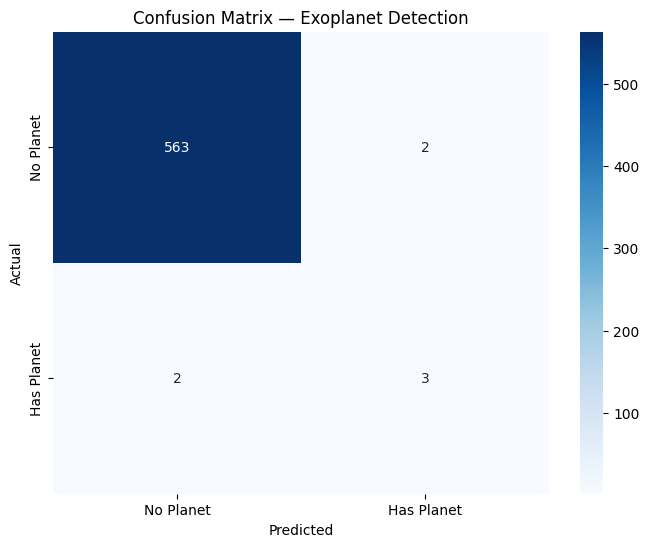

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict on test data
y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Classification report
print(classification_report(y_test, y_pred,
      target_names=['No Planet', 'Has Planet']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Planet', 'Has Planet'],
            yticklabels=['No Planet', 'Has Planet'])
plt.title('Confusion Matrix — Exoplanet Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

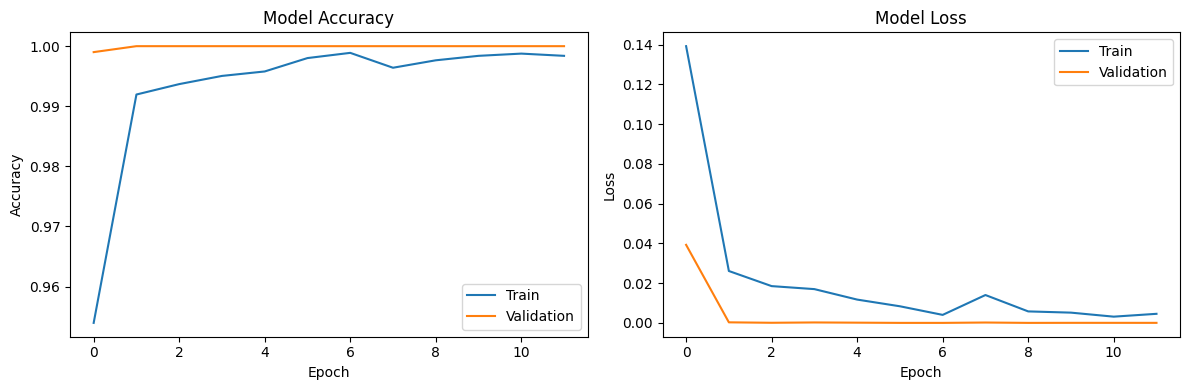

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
model.save('/content/drive/MyDrive/exoplanet/exoplanet_detector.h5')
print("Model saved to Google Drive!")

Model saved to Google Drive!


In [21]:
import os
print(os.listdir('/content/drive/MyDrive/exoplanet/'))

['exoTest.csv', 'exoTrain.csv', 'exoplanet_detector.h5']


In [22]:
import tensorflow as tf

model = tf.keras.models.load_model(
    '/content/drive/MyDrive/exoplanet/exoplanet_detector.h5'
)
print("Model loaded successfully!")
model.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3193, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 3193, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 798, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 798, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 794, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 794, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 198, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 198, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 194, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 194, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       393,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 445,827 (1.70 MB)

 Trainable params: 445,377 (1.70 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocess test data
X_test = test.drop('LABEL', axis=1).values
y_test = test['LABEL'].values - 1

# Normalize
X_test = (X_test - X_test.mean(axis=1, keepdims=True)) / (X_test.std(axis=1, keepdims=True) + 1e-10)

# Reshape for CNN
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Predict
y_pred_prob = model.predict(X_test_cnn)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Results
print(classification_report(y_test, y_pred,
      target_names=['No Planet', 'Has Planet']))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
              precision    recall  f1-score   support

   No Planet       1.00      1.00      1.00       565
  Has Planet       0.60      0.60      0.60         5

    accuracy                           0.99       570
   macro avg       0.80      0.80      0.80       570
weighted avg       0.99      0.99      0.99       570

